In [1]:
# House Price datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "yasserh/housing-prices-dataset"
)

print(dataset_path)

/kaggle/input/datasets/yasserh/housing-prices-dataset


In [2]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['Housing.csv']


In [3]:
# CSV dosyasını okuyoruz

import pandas as pd

df = pd.read_csv(dataset_path + "/Housing.csv")

print(df.shape)

df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 📊 Veri Analizi ve Veri Hazırlama

Bu bölümde veri seti analiz edilerek eksik veriler, veri tipleri ve istatistiksel dağılımlar incelenecektir.

In [4]:
# Veri tiplerini inceliyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Eksik verileri kontrol ediyoruz

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
# Sayısal istatistikleri inceliyoruz

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Gerekli kütüphaneleri import ediyoruz

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

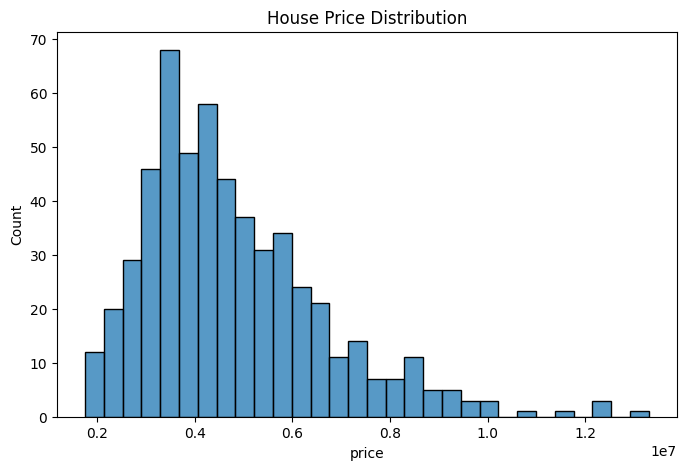

In [8]:
# Ev fiyat dağılımını görselleştiriyoruz

plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

plt.title("House Price Distribution")

plt.show()

# 🤖 Makine Öğrenmesi Modeli

Bu bölümde ev fiyat tahmini için regresyon modelleri oluşturulacak ve performansları karşılaştırılacaktır.

In [9]:
# Kategorik sütunları kesin olarak sayısala çeviriyoruz

df_model = pd.get_dummies(df, drop_first=True)

df_model.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [10]:
# Bağımlı ve bağımsız değişkenleri belirliyoruz

X = df_model.drop("price", axis=1)

y = df_model["price"]

In [11]:
# Train ve test verisini ayırıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Linear Regression modelini eğitiyoruz

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)

print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 970043.4039201636
Linear Regression R2: 0.6529242642153184


In [13]:
# Random Forest modelini eğitiyoruz

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)

print("Random Forest R2:", rf_r2)

Random Forest MAE: 1021546.0353211008
Random Forest R2: 0.611918531405699


In [14]:
# Extra Trees modelini eğitiyoruz

from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_test)

et_mae = mean_absolute_error(y_test, et_pred)

et_r2 = r2_score(y_test, et_pred)

print("Extra Trees MAE:", et_mae)

print("Extra Trees R2:", et_r2)

Extra Trees MAE: 1029499.0871559633
Extra Trees R2: 0.6188270743783898


# ✅ Proje Sonuçları

Bu projede Housing veri seti kullanılarak ev fiyat tahmini gerçekleştirilmiştir.

Veri analizi ve görselleştirme işlemleri yapıldıktan sonra kategorik veriler sayısal hale dönüştürülmüştür.

Daha sonra üç farklı regresyon modeli uygulanmıştır:

- Linear Regression
- Random Forest Regressor
- Extra Trees Regressor

Model karşılaştırmaları sonucunda en başarılı modelin Linear Regression olduğu gözlemlenmiştir.

Bu proje sayesinde:

- Veri analizi
- Veri görselleştirme
- Feature Engineering
- Regression algoritmaları
- House Price Prediction

uygulanmıştır.

##### 